<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SP500_DeepDive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.4/118.4 kB 2.3 MB/s eta 0:00:00
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.61
    Uninstalling yfinance-0.2.61:
      Successfully uninstalled yfinance-0.2.61
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218910 sha256=fa2d52f8ca6d58e56f68565318419f04aa89ee00c41802d0c6d4a5b2290a0487
  Stored in directory: /root/.cache/pip/wheels/7f/33/8b/50b245c5c65433cd8f5cb24ac15d97e5a3db2d41a8b6ae957d
Successfully built pandas_ta
  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=5467225f58049e5452ca034e96a5601cd41ce5b19ac3fbe9401cdcce58a1d930
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [2]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
#import pandas_ta as ta
import numpy as np
import time
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ta
print("Libraries Installed!")

0.2.63
Libraries Installed!


# Monthly Win-rate for SP500

<ipython-input-3-506864197>:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="1993-01-01", end="2024-12-31", progress=False)


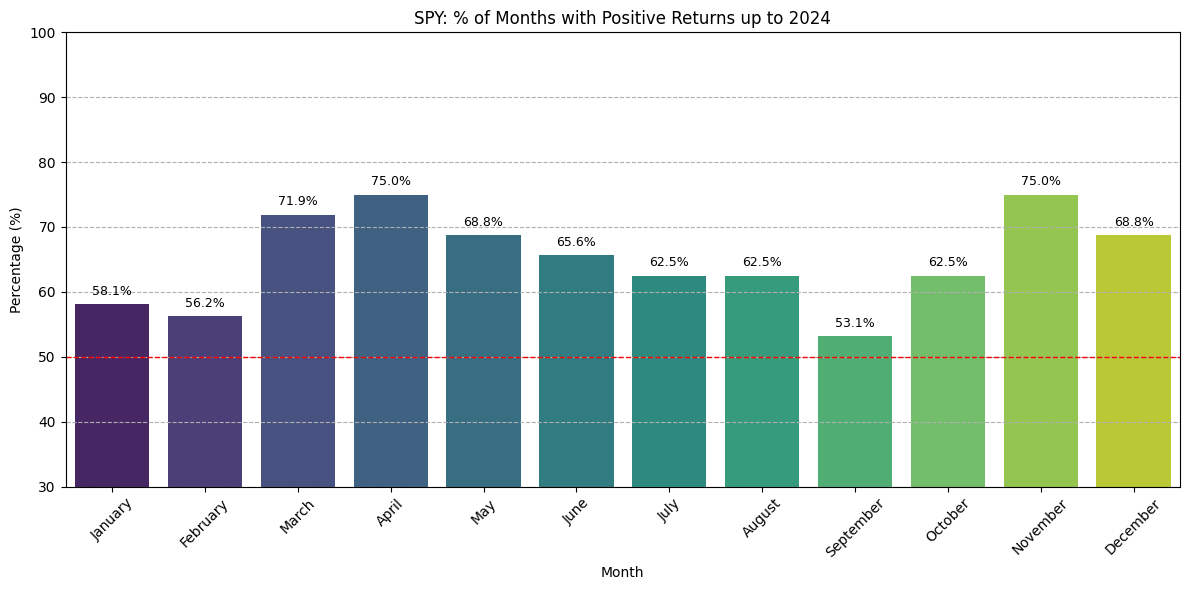

In [3]:
# Step 1: Download SPY historical data
spy = yf.download("SPY", start="1993-01-01", end="2024-12-31", progress=False)

# Step 2: Resample to monthly data and calculate returns
spy_monthly = spy['Close'].resample('ME').last()
monthly_returns = spy_monthly.pct_change().dropna()


# Step 3: Extract month names and whether return was positive
monthly_returns.columns = ['Return']
monthly_returns_df = monthly_returns.copy()
monthly_returns_df['Month'] = monthly_returns_df.index.month_name()
monthly_returns_df['Positive'] = monthly_returns_df['Return'] > 0


# Step 4: Group by month and calculate percent positive
positive_rate = (
    monthly_returns_df.groupby('Month')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Step 5: Order months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
positive_rate['Month'] = pd.Categorical(positive_rate['Month'], categories=month_order, ordered=True)
positive_rate = positive_rate.sort_values('Month')

# Step 6: Plot using Seaborn
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=positive_rate,
    x='Month',
    y='Percent Positive',
    hue='Month',
    palette='viridis',
    legend=False
)

# Annotate each bar with the exact value
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )
# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')
plt.xticks(rotation=45)
plt.title("SPY: % of Months with Positive Returns up to 2024")
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()


#monthly_returns_df.head()

Days of Week

<ipython-input-4-473273627>:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy = yf.download("SPY", start="1993-01-01", end="2024-12-31", progress=False)


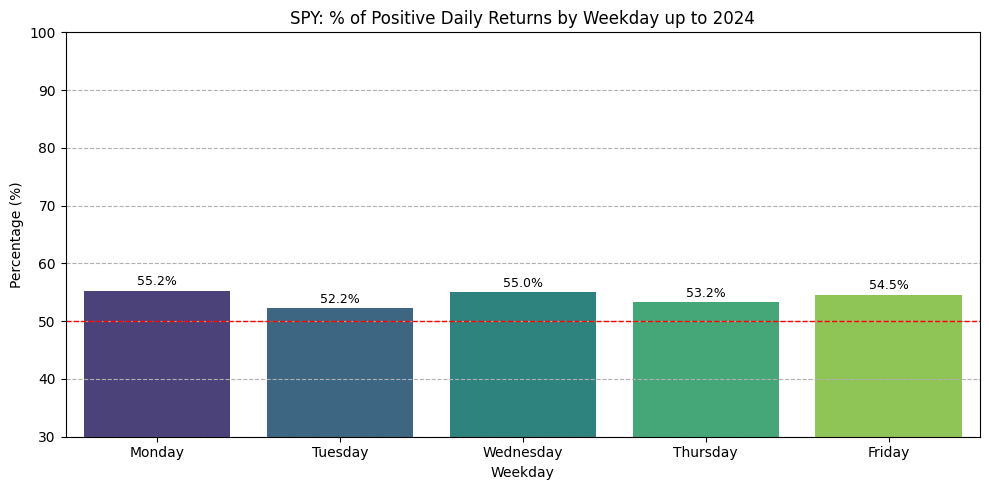

In [4]:
# Step 1: Download SPY historical data
spy = yf.download("SPY", start="1993-01-01", end="2024-12-31", progress=False)

# Step 2: calculate daily returns
spy['Return'] = spy['Close'].pct_change()
spy = spy.dropna()


# Step 3: Add weekday column
spy['Weekday'] = spy.index.day_name()
spy['Positive'] = spy['Return'] > 0



# Step 4: Group by weekday and calculate percentage of positive returns
positive_rate_weekday = (
    spy.groupby('Weekday')['Positive']
    .mean()
    .rename("Percent Positive")
    .mul(100)
    .reset_index()
)

# Ensure days are in Monday–Friday order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
positive_rate_weekday['Weekday'] = pd.Categorical(
    positive_rate_weekday['Weekday'], categories=weekday_order, ordered=True
)
positive_rate_weekday = positive_rate_weekday.sort_values('Weekday')

# Step 5: Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=positive_rate_weekday,
    x='Weekday',
    y='Percent Positive',
    hue='Weekday',
    palette='viridis',
    legend=False
)

# Annotate each bar
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Add horizontal reference line at 50%
plt.axhline(50, color='red', linestyle='--', linewidth=1, label='Neutral (50%)')

# Customize axes and layout
plt.title("SPY: % of Positive Daily Returns by Weekday up to 2024")
plt.ylabel("Percentage (%)")
plt.ylim(30, 100)  # Set scale from 30% to 100%
plt.grid(axis='y', linestyle='--', alpha=1.)
plt.tight_layout()
plt.show()

#spy.head()

# 4-Year Presidential Cycle

[*********************100%***********************]  1 of 1 completed


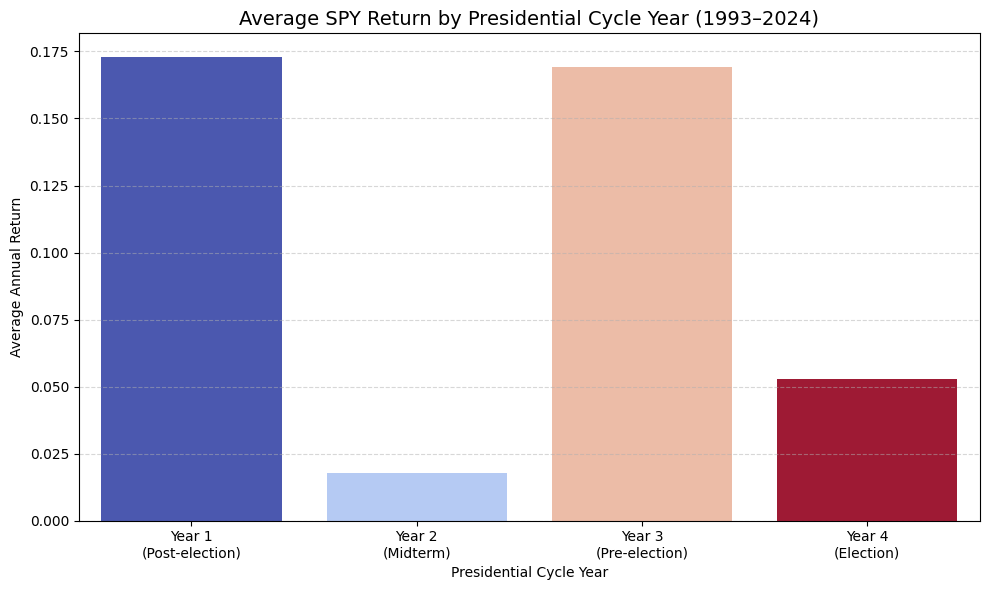

In [27]:

from datetime import datetime

spy = yf.download("SPY", start="1993-01-01", end="2024-12-31", interval="1mo", auto_adjust=False)
spy['Year'] = spy.index.year

# Step 2: Extract year-end closing prices
yearly_close = spy.groupby('Year')['Close'].last()

# Step 3: Calculate annual returns
yearly_close['Return'] = yearly_close['Close'].pct_change()
yearly_close = yearly_close.dropna().reset_index()

# Step 4: Assign presidential cycle year (1993 = Year 1)
def get_cycle_year(year):
    return ((year - 1993) % 4) + 1

yearly_close['CycleYear'] = yearly_close['Year'].apply(get_cycle_year)

# Step 5: Compute average return by cycle year
cycle_stats = yearly_close.groupby('CycleYear')['Return'].agg(['mean', 'median', 'std', 'count']).reset_index()

# Step 6: Plot the result
plt.figure(figsize=(10, 6))
sns.barplot(
    x='CycleYear',
    y='mean',
    data=cycle_stats,
    hue='CycleYear',            # Assign hue explicitly
    palette='coolwarm',         # Still use the same color palette
    legend=False                # Hide redundant legend
)
plt.title('Average SPY Return by Presidential Cycle Year (1993–2024)', fontsize=14)
plt.xlabel('Presidential Cycle Year')
plt.ylabel('Average Annual Return')
plt.xticks([0, 1, 2, 3], ['Year 1\n(Post-election)', 'Year 2\n(Midterm)', 'Year 3\n(Pre-election)', 'Year 4\n(Election)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [28]:
# Optional: Display table
print(cycle_stats.round(4))

   CycleYear    mean  median     std  count
0          1  0.1731  0.2349  0.1636      7
1          2  0.0176  0.0454  0.1746      8
2          3  0.1693  0.2170  0.1416      8
3          4  0.0529  0.1156  0.2040      8


Weinstein Stages

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_monthly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1mo", progress=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_prev'] = data['SMA_30'].shift(1)
    data['SMA_slope'] = data['SMA_30'] - data['SMA_prev']
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Below_SMA']) & (data['SMA_slope'] >= 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] <= 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0)
    ]
    stages = [1, 2, 3, 4]
    data['Month'] = data.index.month_name()

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each month (it's monthly data already)
    data = data[['Month','Stage']]
    data = data.dropna()

    return data[['Month','Stage']]

def aggregate_stage_counts(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_monthly(ticker)
        if result is not None:
            all_data.append(result)

    if not all_data:
        return None

    combined_df = pd.concat(all_data)
    stage_counts = combined_df.groupby(['Month', 'Stage']).size().unstack(fill_value=0)

    return stage_counts


# Main
#if __name__ == "__main__":
    #tickers = get_sp500_tickers()
    #print(f"Loaded {len(tickers)} tickers")
    #excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    #tickers = [item for item in tickers if item not in excluded]
    #y= classify_stages_monthly(tickers)
    #print(y.head())
    #print(y)
    #print(classify_stages_monthly('AAPL'))



    #stage_counts = aggregate_stage_counts(tickers)
    #print(stage_counts.tail())

In [ ]:
# Step 1: Reshape and prepare data
#df_melted = stage_counts.reset_index().melt(id_vars='Month', var_name='Stage', value_name='Count')

# Step 2: Ensure chronological month order (even if not all months are present)
#month_order = [
    #'January', 'February', 'March', 'April', 'May', 'June',
    #'July', 'August', 'September', 'October', 'November', 'December'
#]
#df_melted['Month'] = pd.Categorical(df_melted['Month'], categories=month_order, ordered=True)
#df_melted = df_melted.sort_values('Month')

# Step 3: Plot
#plt.figure(figsize=(12, 6))
#sns.lineplot(data=df_melted, x='Month', y='Count', hue='Stage', marker='o')
#plt.title("Weinstein Stage Counts per Month (2025)")
#plt.xlabel("Month")
#plt.ylabel("Number of Stocks")
#plt.xticks(rotation=45)
#plt.grid(True)
#plt.tight_layout()
#plt.show()

# Weinstien Stages by Week

In [ ]:
# Step 1: Get S&P 500 tickers from Wikipedia
def get_sp500_tickers():
    df = pd.read_csv('SP500.csv')
    tickers = df['Symbol'].tolist()
    return tickers

# Step 2,3,4: Define a function to classify stages for a single ticker
def classify_stages_weekly(ticker):
    # Fetch monthly data for past ~10 years (adjust as needed)
    data = yf.download(ticker, period="3y", interval="1wk", progress=False)
    if data.empty or len(data) < 35:
        print(f"Not enough data for {ticker}")
        pass
        #return None  # Not enough data to compute 30-month SMA

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    # Backfill missing values
    data = data.bfill()
    data['SMA_prev'] = data['SMA_30'].shift(1)
    data['SMA_slope'] = data['SMA_30'] - data['SMA_prev']
    # Use numpy arrays for comparison
    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()


    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    # Define stages
    conditions = [
        (data['Price_Below_SMA']) & (data['SMA_slope'] >= 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),
        (data['Price_Above_SMA']) & (data['SMA_slope'] <= 0),
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0)
    ]
    stages = [1, 2, 3, 4]
    data['Week'] = data.index.to_period("W").start_time # data.index.to_period('W').astype(str)

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    # Only keep 2025 data
    data = data[data.index.year == 2025]
    if data.empty:
        return None
    # Keep only the last date of each
    data = data[['Week', 'Stage']].dropna()
    data = data.dropna()

    return data[['Week','Stage']]

def aggregate_stage_counts(tickers):
    import pandas as pd

    all_data = []

    for ticker in tickers:
        result = classify_stages_weekly(ticker)
        if result is not None:
            all_data.append(result)

    if not all_data:
        return None

    combined_df = pd.concat(all_data)
    stage_counts = combined_df.groupby(['Week', 'Stage']).size().unstack(fill_value=0)

    return stage_counts, combined_df


# Main
if __name__ == "__main__":
    tickers = get_sp500_tickers()
    print(f"Loaded {len(tickers)} tickers")
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [item for item in tickers if item not in excluded]
    #y= classify_stages_monthly(tickers)
    #print(y.head())
    #print(y)
    #print(classify_stages_monthly('AAPL'))



    stage_counts, combined_df = aggregate_stage_counts(tickers)
    print(stage_counts.tail())

Loaded 503 tickers
Stage       1.0  2.0  3.0  4.0
Week                          
2025-04-28   49  164   32  250
2025-05-05   30  175   38  252
2025-05-12   22  205   84  184
2025-05-19   28  186   45  235
2025-05-26   37  203   38  216


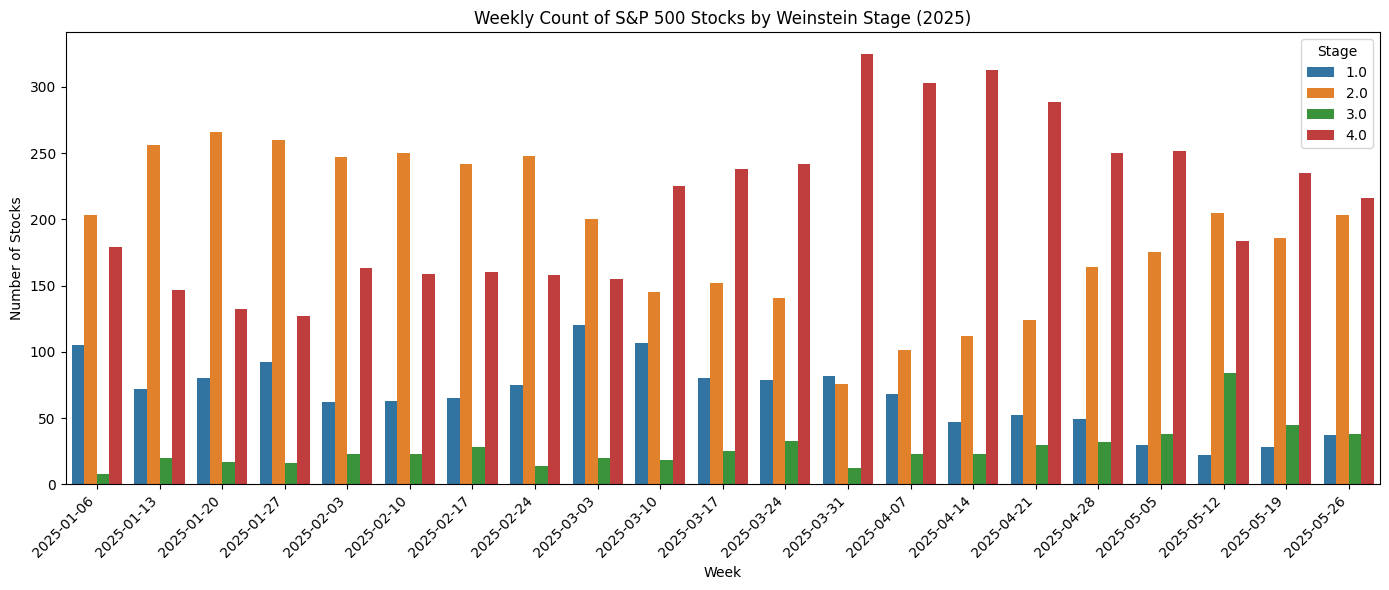

In [ ]:
 # Plot stage distribution by week
plt.figure(figsize=(14, 6))
sns.countplot(data=combined_df, x='Week', hue='Stage', palette='tab10')
plt.title("Weekly Count of S&P 500 Stocks by Weinstein Stage (2025)")
plt.xlabel("Week")
plt.ylabel("Number of Stocks")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title="Stage")
plt.show()

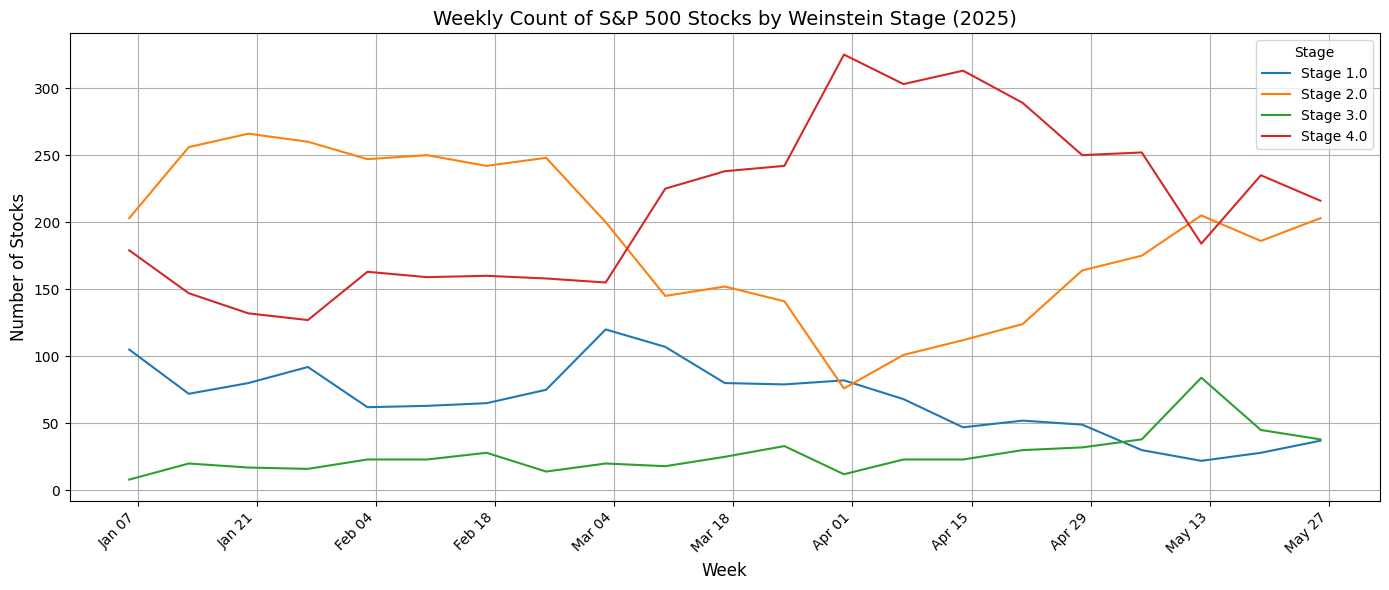

In [ ]:
# plot line chart
stage_counts_reset = stage_counts.reset_index()

plt.figure(figsize=(14, 6))

for stage in stage_counts.columns:
    plt.plot(stage_counts_reset['Week'], stage_counts_reset[stage], label=f"Stage {stage}")

plt.title("Weekly Count of S&P 500 Stocks by Weinstein Stage (2025)", fontsize=14)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Number of Stocks", fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45, ha='right')
plt.legend(title="Stage")
plt.tight_layout()
plt.grid(True)
plt.show()

 Filte stocks by stages 2 and 4

# Confirm Stages by Week

In [ ]:
def classify_stages_weekly(ticker):
    import yfinance as yf
    import numpy as np
    import pandas as pd

    data = yf.download(ticker, period="3y", interval="1wk", progress=False)
    if data.empty or len(data) < 35:
        return None

    data['SMA_30'] = data['Close'].rolling(window=30).mean()
    data = data.bfill()

    data['SMA_prev'] = data['SMA_30'].shift(1)
    data['SMA_slope'] = data['SMA_30'] - data['SMA_prev']

    close_vals = data['Close'].to_numpy().astype(float).ravel()
    sma_vals = data['SMA_30'].to_numpy().astype(float).ravel()
    data['Price_Above_SMA'] = close_vals > sma_vals
    data['Price_Below_SMA'] = close_vals < sma_vals

    conditions = [
        (data['Price_Below_SMA']) & (data['SMA_slope'] >= 0),  # Stage 1
        (data['Price_Above_SMA']) & (data['SMA_slope'] > 0),   # Stage 2
        (data['Price_Above_SMA']) & (data['SMA_slope'] <= 0),  # Stage 3
        (data['Price_Below_SMA']) & (data['SMA_slope'] < 0)    # Stage 4
    ]
    stages = [1, 2, 3, 4]

    data['Stage'] = np.select(conditions, stages, default=np.nan)
    #data = data.dropna(subset=['Stage'])

    # Filter for 2025 only
    data = data[data.index.year == 2025]
    if data.empty:
        return None

    latest = data.iloc[-1]
    return pd.DataFrame({
        'Ticker': [ticker],
        'Week': [latest.name.strftime('%Y-%m-%d')],
        'Stage': [int(latest['Stage'].iloc[0]) if isinstance(latest['Stage'], pd.Series) else int(latest['Stage'])]
    })

def get_weekly_stage_screener(tickers):
    results = []
    for ticker in tickers:
        res = classify_stages_weekly(ticker)
        if res is not None:
            results.append(res)

    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame(columns=['Ticker', 'Week', 'Stage'])


if __name__ == "__main__":
    import pandas as pd

    tickers = get_sp500_tickers()
    excluded = ['BRK.B', 'BF.B','GEV', 'KVUE','GEHC','SW','VLTO','SOLV']
    tickers = [t for t in tickers if t not in excluded]

    screener_df = get_weekly_stage_screener(tickers)
    print("All weekly results (latest 2025):")
    print(screener_df.head())

    # Filter for bullish or bearish trends (Stage 2 and 3)
    filtered_df = screener_df[screener_df['Stage'].isin([2, 3])]
    print(f"\nFiltered (Stage 2 & 3):\n{filtered_df}")

    # Save to CSV
    filtered_df.to_csv("weekly_stage_2_3_stocks_2025.csv", index=False)
    print("\nSaved to 'weekly_stage_2_3_stocks_2025.csv'")

All weekly results (latest 2025):
  Ticker        Week  Stage
0   AAPL  2025-05-26      4
1   NVDA  2025-05-26      3
2   MSFT  2025-05-26      2
3   AMZN  2025-05-26      1
4  GOOGL  2025-05-26      1

Filtered (Stage 2 & 3):
    Ticker        Week  Stage
1     NVDA  2025-05-26      3
2     MSFT  2025-05-26      2
6     META  2025-05-26      2
7     TSLA  2025-05-26      2
8     AVGO  2025-05-26      2
..     ...         ...    ...
476   HSIC  2025-05-26      2
480   PARA  2025-05-26      2
484    MOS  2025-05-26      2
490    HII  2025-05-26      2
491    BWA  2025-05-26      3

[242 rows x 3 columns]

Saved to 'weekly_stage_2_3_stocks_2025.csv'
